In [1]:
import warnings
import copy

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [2]:
adata_age_cd4= sc.read_h5ad("/scratch/user/s4575250/BIOX7014_Thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")

In [3]:
print(adata_age_cd4)

AnnData object with n_obs × n_vars = 596486 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in 

In [4]:
adata_age_cd4.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      151860
4–6      134748
7–10      91711
11–14    162356
15–18     55811
Name: count, dtype: int64

In [5]:
adata_age_cd4.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     6493
0.07     7871
0.14     1576
0.35     6804
0.48     6077
         ... 
16.16    5594
16.20    5700
16.29    3669
16.78    4525
17.03    7608
Name: count, Length: 122, dtype: int64

In [6]:
adata_age_cd4.obs["Sex"].value_counts().sort_index()

Sex
Female    274649
Male      321837
Name: count, dtype: int64

In [7]:
adata_age_cd4.obs["Age"].value_counts().sort_index()

Age
0     52475
1     20322
2     39325
3     39738
4     59464
5     27998
6     47286
7     34567
8     25099
9     18081
10    13964
11    47405
12    28930
13    37178
14    48843
15    23877
16    24326
17     7608
Name: count, dtype: int64

In [8]:
adata_age_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_cd4.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD4 naive/Tcm    407516
CD4 Tem           96510
Tfh               45002
Treg              39431
CD4 cytoT          8027
Name: count, dtype: int64

In [9]:
adata_age_cd4.obs["Batch"] = adata_age_cd4.obs["Batch"].astype("category")
adata_age_cd4.obs["Age_years"] = adata_age_cd4.obs["Age_years"].astype("float")
adata_age_cd4.obs["Sex"] = adata_age_cd4.obs["Sex"].astype("category")
adata_age_cd4.obs["Age"] = adata_age_cd4.obs["Age"].astype("int")

In [10]:
adata_age_cd4.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     6493
0.07     7871
0.14     1576
0.35     6804
0.48     6077
         ... 
16.16    5594
16.20    5700
16.29    3669
16.78    4525
17.03    7608
Name: count, Length: 122, dtype: int64

In [11]:
adata_age_cd4.obs["Batch"].value_counts().sort_index()

Batch
Batch01      9907
Batch02    109800
Batch03    111249
Batch04    128208
Batch05     69259
Batch06    102859
Batch07     65204
Name: count, dtype: int64

In [12]:
adata_age_cd4.obs.groupby("pica_id")["Age_years"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [1.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age_years, Length: 128, dtype: object

In [13]:
adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [14]:
adata_age_cd4.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [15]:
""" Age group
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="cell_type",   
    sample_col="pica_id",       
    covariates=("Age_group","Child's sex"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data
"""

' Age group\n# build sccoda input from cell-level data\ndef make_sccoda_from_lineage(\n    adata,\n    cell_type_col="cell_type",   \n    sample_col="pica_id",       \n    covariates=("Age_group","Child\'s sex"), \n):\n    sccoda_data = sccoda_model.load(\n        adata,\n        type="cell_level",\n        generate_sample_level=True,\n        cell_type_identifier=cell_type_col,\n        sample_identifier=sample_col,\n        covariate_obs=list(covariates),\n    )\n    return sccoda_data\n'

In [16]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="pica_cell_type_complete_01_gdT_corrected",   
    sample_col="pica_id",       
    covariates=("Age_years","Sex", "Batch","Age"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [17]:
sccoda_cd4 = make_sccoda_from_lineage(adata_age_cd4, cell_type_col="pica_cell_type_complete_01_gdT_corrected")

In [18]:
sccoda_cd4

MuData object with n_obs × n_vars = 596614 × 38611
  2 modalities
    rna:	596486 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	128 x 5
      obs:	'Sex', 'Age_years', 'pica_id', 'Batch', 'Age'
      var:	'n_cells'

## Run sccoda

In [19]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda", ref="automatic"):
    formula = "~ Age_years * Sex + Batch"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type=ref,  # or e.g. "CD4_naive"
    )
    return sccoda_data

In [20]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data


#### automatic ref cell type model (Treg)

In [27]:
cd4_auto = prepare_sccoda_age(sccoda_cd4.copy(), ref="automatic")

• Automatic reference selection! Reference cell type set to Treg
• Zero counts encountered in data! Added a pseudocount of 0.5.


In [28]:
cd4_auto = run_sccoda(cd4_auto, rng_key=1)

sample: 100%|██████████| 7000/7000 [11:50<00:00,  9.85it/s, 1023 steps of size 2.36e-03. acc. prob=0.99]


! Acceptance rate unusually high (0.9906963513559705 > 0.95)! Results might be incorrect! Please check feasibility of results and re-run the sampling step with a different rng_key if necessary.


In [29]:
sccoda_model.summary(cd4_auto, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 5 cell types                                         │
│ Reference cell type                   │ Treg                                                                    │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 4                                                                       │
│ Spike-and-slab threshold              │ 0.885                                                                   │
│ Spike-and-slab threshold              │ 0.885                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 99.1%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD4 Tem                                        1.100        0.869   1.320  0.119      317.509                   │
│ CD4 cytoT                                     -0.625       -0.954  -0.267  0.183       56.571                   │
│ CD4 naive/Tcm                                  3.544        3.360   3.749  0.114     3657.390                   │
│ Tfh                                            0.924        0.701   1.182  0.130      266.268                   │
│ Treg                                           1.232        1.098   1.374  0.074      362.312                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  Expected Sample  log2-fold change                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem            0.000            317.509            0.000                                │
│                     CD4 cytoT          0.000             56.571            0.000                                │
│                     CD4 naive/Tcm      0.000           3657.390            0.000                                │
│                     Tfh                0.000            266.268            0.000                                │
│                     Treg               0.000            362.312            0.000                                │
│ BatchT.Batch02      CD4 Tem            0.000            317.509            0.000                                │
│                     CD4 cytoT          0.000             56.571            0.000                                │
│                     CD4 naive/Tcm      0.000           3657.390            0.000                                │
│                     Tfh                0.000            266.268            0.000                                │
│                     Treg               0.000            362.312            0.000                                │
│ BatchT.Batch03      CD4 Tem            0.000            317.509            0.000                                │
│                     CD4 cytoT          0.000             56.571            0.000                                │
│                     CD4 naive/Tcm      0.000           3657.390            0.000                                │
│                     Tfh                0.000            266.268            0.000                                │
│                     Treg               0.000            362.312            0.000                                │
│ BatchT.Batch04      CD4 Tem            0.000            317.509            0.000                                │
│                     CD4 cytoT          0.000             56.571            0.000                                │
│                     CD4 naive/Tcm      0.000           3657.390            0.000                                │
│                     Tfh                0.000            266.268            0.000                                │
│                     Treg               0.000            362.312            0.000                                │
│ BatchT.Batch05      CD4 Tem            0.000            317.509            0.000                                │
│                     CD4 cytoT          0.000             56.571            0.000                                │
│                     CD4 naive/Tcm      0.000           3657.390            0.000                                │
│                     Tfh                0.000            266.268            0.000                                │
│                     Treg               0.000            362.312            0.000                                │
│ BatchT.Batch06      CD4 Tem            0.000            317.509            0.000                                │
│                     CD4 cytoT          0.000             56.571            0.000                                │
│                     CD4 naive/Tcm      0.000           3657.390            0.000                                │
│                     Tfh                0.000            266.268            0.000                                │
│                     Treg               0.000          

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    HDI 3%  HDI 97%   SD   Inclusion probability                                 │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem        -0.263  0.051   0.074         0.441                                          │
│                     CD4 cytoT      -0.347  0.232   0.102         0.414                                          │
│                     CD4 naive/Tcm  -0.148  0.173   0.047         0.321                                          │
│                     Tfh            -0.305  0.062   0.090         0.471                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch02      CD4 Tem        -0.124  0.158   0.043         0.320                                          │
│                     CD4 cytoT      -0.174  0.363   0.096         0.420                                          │
│                     CD4 naive/Tcm  -0.170  0.120   0.063         0.309                                          │
│                     Tfh            -0.171  0.144   0.049         0.346                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch03      CD4 Tem        -0.089  0.179   0.043         0.315                                          │
│                     CD4 cytoT      -0.216  0.275   0.080         0.394                                          │
│                     CD4 naive/Tcm  -0.203  0.077   0.069         0.342                                          │
│                     Tfh            -0.105  0.210   0.055         0.360                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch04      CD4 Tem        -0.165  0.091   0.040         0.314                                          │
│                     CD4 cytoT      -0.255  0.223   0.075         0.376                                          │
│                     CD4 naive/Tcm  -0.098  0.159   0.058         0.294                                          │
│                     Tfh            -0.123  0.197   0.050         0.341                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch05      CD4 Tem        -0.156  0.272   0.075         0.352                                          │
│                     CD4 cytoT      -0.168  0.526   0.152         0.494                                          │
│                     CD4 naive/Tcm  -0.374  0.007   0.134         0.807                                          │
│                     Tfh            -0.211  0.247   0.071         0.352                                          │
│                     Treg            0.000  0.000   0.000         0.000                                          │
│ BatchT.Batch06      CD4 Tem        -0.113  0.174   0.046         0.339                                          │
│                     CD4 cytoT      -0.489  0.109   0.139         0.481                                          │
│                     CD4 naive/Tcm  -0.180  0.104   0.066         0.318                                          │
│                     Tfh            -0.156  0.171   0.050         0.334                                          │
│                     Treg            0.000  0.000   0.0

In [30]:
# set desired FDR globally
sccoda_model.set_fdr(cd4_auto, est_fdr=0.2, modality_key="coda")


In [31]:
# check threshold
cd4_auto["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.501)

In [32]:
effects_cd4_auto = sccoda_model.get_effect_df(cd4_auto, modality_key="coda")

effects_cd4_auto["Inclusion probability"].max()
effects_cd4_auto["Inclusion probability"].describe()


count    45.000000
mean      0.329044
std       0.245510
min       0.000000
25%       0.229400
50%       0.339000
75%       0.412600
max       1.000000
Name: Inclusion probability, dtype: float64

In [33]:

# effects dataframe
effects_cd4_auto = sccoda_model.get_effect_df(cd4_auto, modality_key="coda")
effects_cd4_auto.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                
SexT.Male CD4 Tem                    0.0  -0.263    0.051  0.074   
          CD4 cytoT                  0.0  -0.347    0.232  0.102   
          CD4 naive/Tcm              0.0  -0.148    0.173  0.047   
          Tfh                        0.0  -0.305    0.062  0.090   
          Treg                       0.0   0.000    0.000  0.000   

                         Inclusion probability  Expected Sample  \
Covariate Cell Type                                               
SexT.Male CD4 Tem                       0.4414       317.508677   
          CD4 cytoT                     0.4142        56.571490   
          CD4 naive/Tcm                 0.3214      3657.390334   
          Tfh                           0.4714       266.268487   
          Treg                          0.0000       362.311793   

                         log2-fold change  
Covariate Cell Type                        
SexT.Male CD4 Tem                     0.0  
          CD4 cytoT                   0.0  
          CD4 naive/Tcm               0.0  
          Tfh                         0.0  
          Treg                        0.0

In [34]:
# counts per sample x celltype
counts = pd.DataFrame(
    cd4_auto["coda"].X,
    index=cd4_auto["coda"].obs_names,
    columns=cd4_auto["coda"].var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = cd4_auto["coda"].obs.copy()

# long format for plotting
df = (
    props.join(meta[["Age_years", "Age"]])
    .reset_index(names="sample")
    .melt(
        id_vars=["sample", "Age_years", "Age"],
        var_name="pica_cell_type_complete_01_gdT_corrected",
        value_name="Proportion",
    )
)

In [35]:
df["pica_cell_type_complete_01_gdT_corrected"].unique()

array(['CD4 Tem', 'CD4 cytoT', 'CD4 naive/Tcm', 'Tfh', 'Treg'],
      dtype=object)

In [36]:
df["Age"].unique()

array([ 2, 15,  0,  1,  9,  3,  4,  5, 13,  6,  7, 10, 16, 12, 11, 14,  8,
       17])

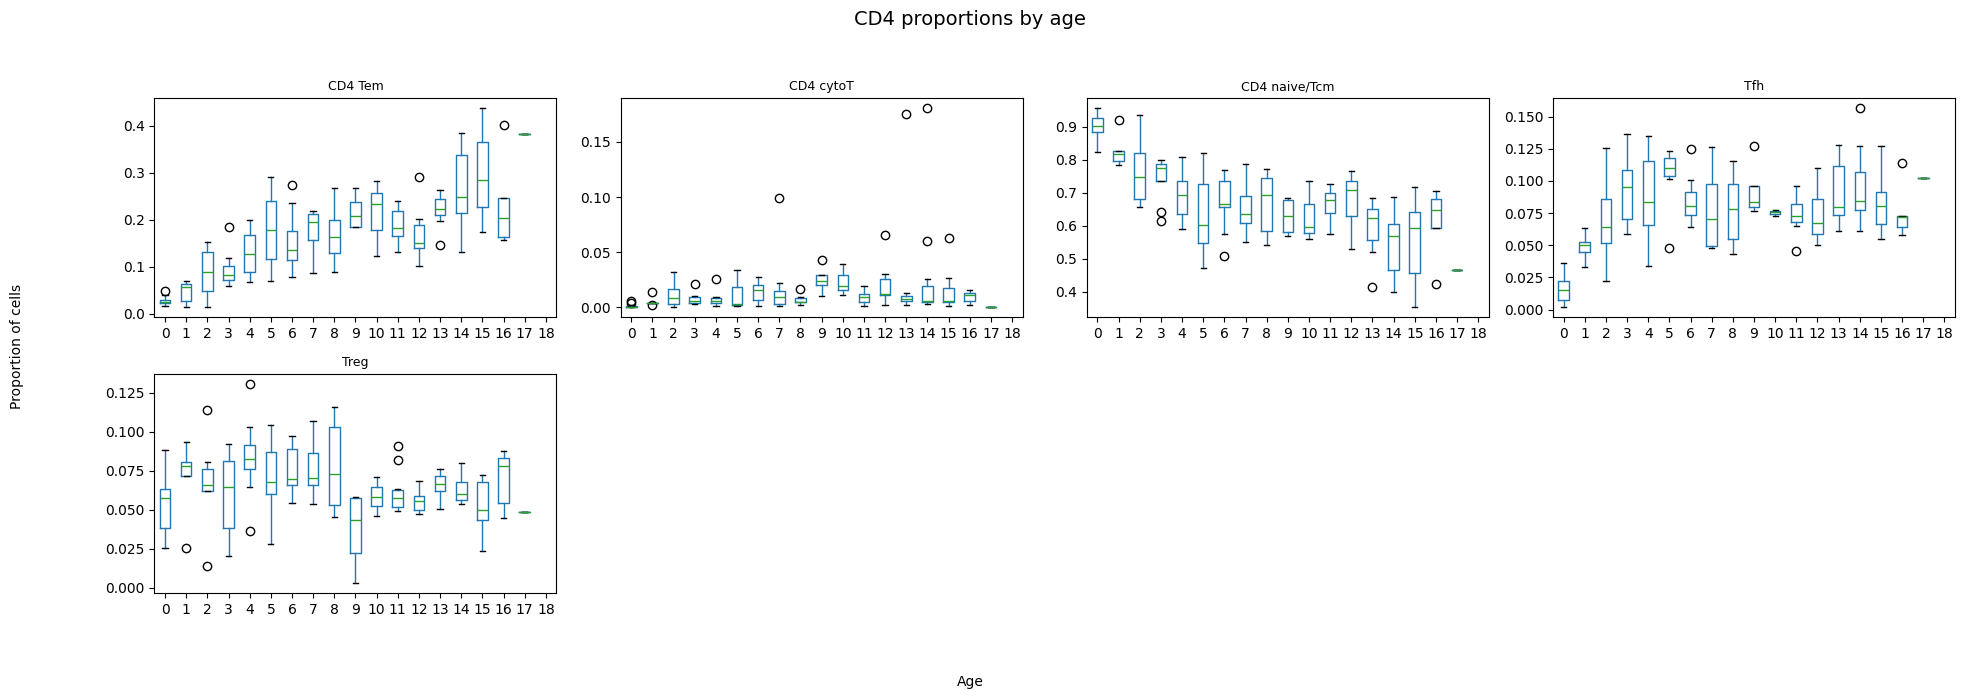

In [37]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["pica_cell_type_complete_01_gdT_corrected"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["pica_cell_type_complete_01_gdT_corrected"] == cell]
    sub.boxplot(column="Proportion", by="Age", grid=False, ax=ax)

    ax.set_xticks(range(1, 20))
    ax.set_xticklabels(range(0, 19))
    ax.set_xlim(0.5, 19.5)

    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("CD4 proportions by age", fontsize=14)
fig.supxlabel("Age", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

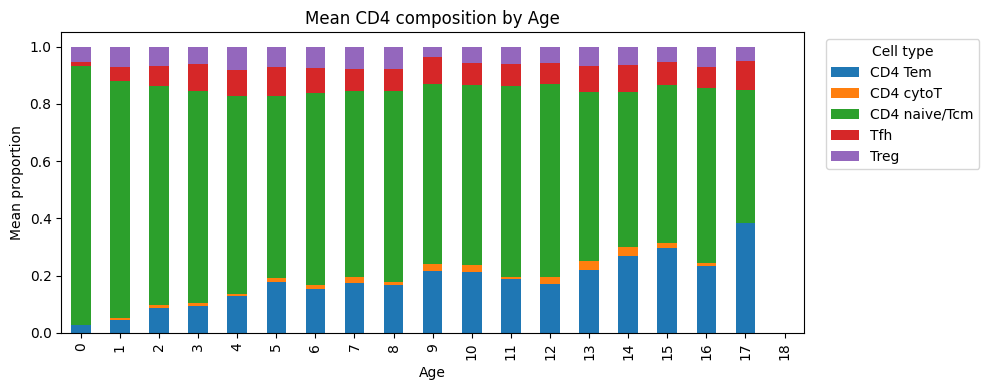

In [38]:
# barplot of composition by age group
props_age = (props.join(meta["Age"]).groupby("Age").mean().reindex(range(0, 19)))

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean CD4 composition by Age")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

In [47]:
# Filter out Batch before plotting
effects_cd4_auto_plot = effects_cd4_auto[
    ~effects_cd4_auto.index.get_level_values("Covariate").str.startswith("Batch")
]

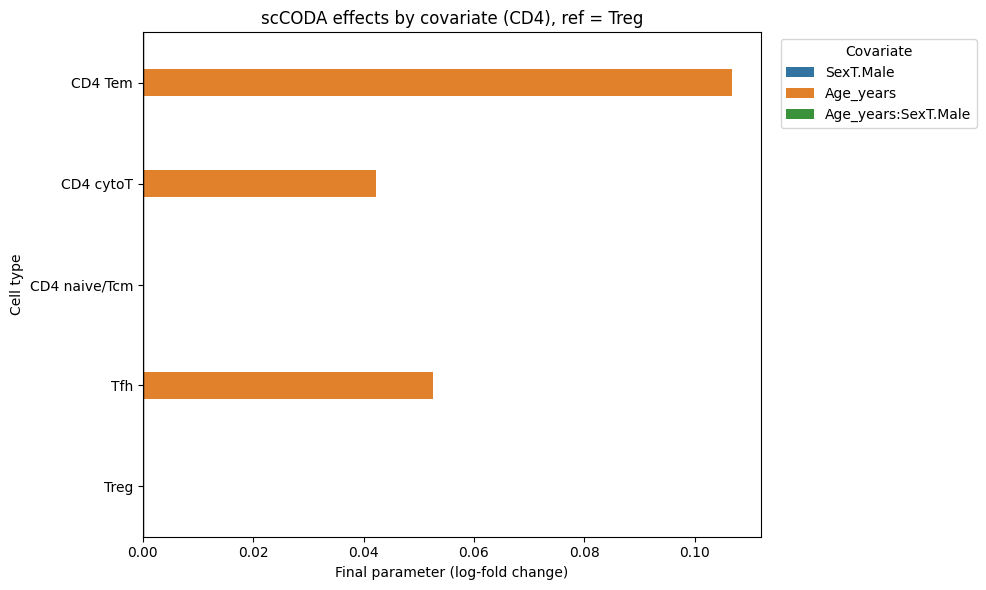

In [48]:
# effect barplot 
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd4_auto_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD4), ref = Treg")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

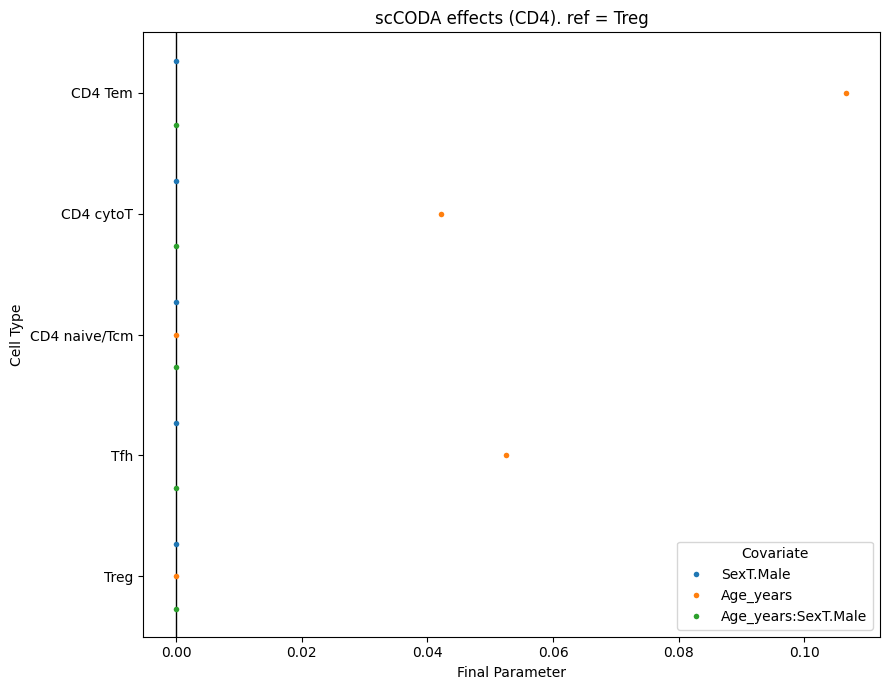

In [49]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd4_auto_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD4). ref = Treg")
plt.tight_layout()
plt.show()

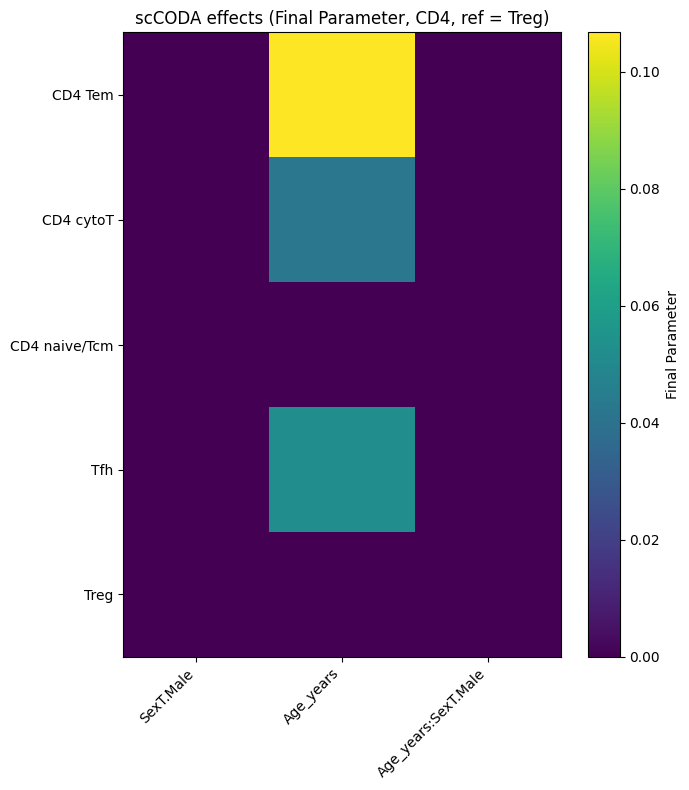

In [50]:
# inclusion pronbability heatmap
tmp_auto = effects_cd4_auto_plot.reset_index()
ip_auto = tmp_auto.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_auto = effects_cd4_auto_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_auto.values, aspect="auto")
plt.yticks(range(beta_auto.shape[0]), beta_auto.index)
plt.xticks(range(beta_auto.shape[1]), beta_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD4, ref = Treg)")
plt.tight_layout()
plt.show()

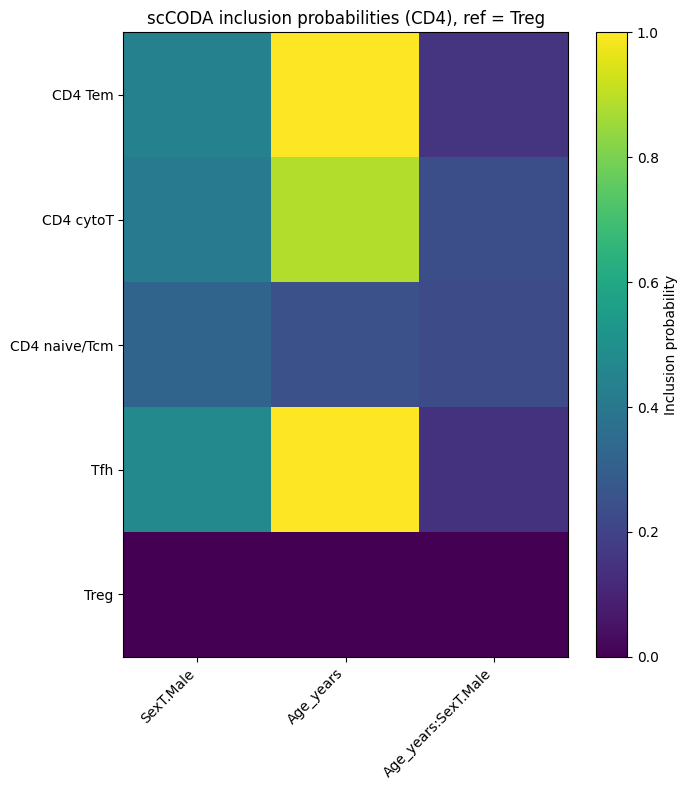

In [51]:
ip_auto = effects_cd4_auto_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_auto.values, aspect="auto")
plt.yticks(range(ip_auto.shape[0]), ip_auto.index)
plt.xticks(range(ip_auto.shape[1]), ip_auto.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD4), ref = Treg")
plt.tight_layout()
plt.show()


#### ref cell type model (CD4 naive/Tcm)

In [21]:
cd4_naive = prepare_sccoda_age(sccoda_cd4.copy(), ref="CD4 naive/Tcm")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [22]:
cd4_naive = run_sccoda(cd4_naive, rng_key=1)

sample: 100%|██████████| 7000/7000 [10:10<00:00, 11.47it/s, 1023 steps of size 5.52e-03. acc. prob=0.90]


In [23]:
sccoda_model.summary(cd4_naive, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 5 cell types                                         │
│ Reference cell type                   │ CD4 naive/Tcm                                                           │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 2                                                                       │
│ Spike-and-slab threshold              │ 0.945                                                                   │
│ Spike-and-slab threshold              │ 0.945                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 89.7%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD4 Tem                                        1.043        0.859   1.236  0.102      323.381                   │
│ CD4 cytoT                                     -0.663       -0.960  -0.323  0.169       58.723                   │
│ CD4 naive/Tcm                                  3.468        3.340   3.603  0.070     3654.924                   │
│ Tfh                                            0.870        0.667   1.091  0.112      272.008                   │
│ Treg                                           1.125        0.903   1.356  0.121      351.016                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  Expected Sample  log2-fold change                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem            0.000            323.381            0.000                                │
│                     CD4 cytoT          0.000             58.723            0.000                                │
│                     CD4 naive/Tcm      0.000           3654.924            0.000                                │
│                     Tfh                0.000            272.008            0.000                                │
│                     Treg               0.000            351.016            0.000                                │
│ BatchT.Batch02      CD4 Tem            0.000            323.381            0.000                                │
│                     CD4 cytoT          0.000             58.723            0.000                                │
│                     CD4 naive/Tcm      0.000           3654.924            0.000                                │
│                     Tfh                0.000            272.008            0.000                                │
│                     Treg               0.000            351.016            0.000                                │
│ BatchT.Batch03      CD4 Tem            0.000            323.381            0.000                                │
│                     CD4 cytoT          0.000             58.723            0.000                                │
│                     CD4 naive/Tcm      0.000           3654.924            0.000                                │
│                     Tfh                0.000            272.008            0.000                                │
│                     Treg               0.000            351.016            0.000                                │
│ BatchT.Batch04      CD4 Tem            0.000            323.381            0.000                                │
│                     CD4 cytoT          0.000             58.723            0.000                                │
│                     CD4 naive/Tcm      0.000           3654.924            0.000                                │
│                     Tfh                0.000            272.008            0.000                                │
│                     Treg               0.000            351.016            0.000                                │
│ BatchT.Batch05      CD4 Tem            0.000            323.381            0.000                                │
│                     CD4 cytoT          0.000             58.723            0.000                                │
│                     CD4 naive/Tcm      0.000           3654.924            0.000                                │
│                     Tfh                0.000            272.008            0.000                                │
│                     Treg               0.000            351.016            0.000                                │
│ BatchT.Batch06      CD4 Tem            0.000            323.381            0.000                                │
│                     CD4 cytoT          0.000             58.723            0.000                                │
│                     CD4 naive/Tcm      0.000           3654.924            0.000                                │
│                     Tfh                0.000            272.008            0.000                                │
│                     Treg               0.000          

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    HDI 3%  HDI 97%   SD   Inclusion probability                                 │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem        -0.166  0.054   0.043         0.348                                          │
│                     CD4 cytoT      -0.324  0.218   0.093         0.382                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.239  0.061   0.065         0.390                                          │
│                     Treg           -0.135  0.191   0.050         0.336                                          │
│ BatchT.Batch02      CD4 Tem        -0.132  0.121   0.036         0.309                                          │
│                     CD4 cytoT      -0.158  0.359   0.095         0.406                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.188  0.120   0.049         0.341                                          │
│                     Treg           -0.244  0.105   0.066         0.375                                          │
│ BatchT.Batch03      CD4 Tem        -0.101  0.145   0.037         0.315                                          │
│                     CD4 cytoT      -0.262  0.218   0.077         0.397                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.098  0.222   0.054         0.349                                          │
│                     Treg           -0.081  0.304   0.083         0.434                                          │
│ BatchT.Batch04      CD4 Tem        -0.165  0.106   0.045         0.351                                          │
│                     CD4 cytoT      -0.288  0.207   0.080         0.378                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.146  0.152   0.045         0.328                                          │
│                     Treg           -0.152  0.179   0.052         0.347                                          │
│ BatchT.Batch05      CD4 Tem        -0.022  0.322   0.098         0.563                                          │
│                     CD4 cytoT      -0.129  0.554   0.167         0.534                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.131  0.269   0.072         0.374                                          │
│                     Treg           -0.085  0.408   0.120         0.501                                          │
│ BatchT.Batch06      CD4 Tem        -0.111  0.159   0.044         0.327                                          │
│                     CD4 cytoT      -0.512  0.098   0.144         0.496                                          │
│                     CD4 naive/Tcm   0.000  0.000   0.000         0.000                                          │
│                     Tfh            -0.164  0.167   0.051         0.336                                          │
│                     Treg           -0.047  0.388   0.1

In [24]:
# set desired FDR globally
sccoda_model.set_fdr(cd4_naive, est_fdr=0.2, modality_key="coda")


In [25]:
# check threshold
cd4_naive["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.533)

In [26]:
effects_cd4_naive = sccoda_model.get_effect_df(cd4_naive, modality_key="coda")

effects_cd4_naive["Inclusion probability"].max()
effects_cd4_naive["Inclusion probability"].describe()


count    45.000000
mean      0.334987
std       0.244145
min       0.000000
25%       0.210400
50%       0.348800
75%       0.406400
max       1.000000
Name: Inclusion probability, dtype: float64

In [27]:

# effects dataframe
effects_cd4_naive = sccoda_model.get_effect_df(cd4_naive, modality_key="coda")
effects_cd4_naive.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                
SexT.Male CD4 Tem                    0.0  -0.166    0.054  0.043   
          CD4 cytoT                  0.0  -0.324    0.218  0.093   
          CD4 naive/Tcm              0.0   0.000    0.000  0.000   
          Tfh                        0.0  -0.239    0.061  0.065   
          Treg                       0.0  -0.135    0.191  0.050   

                         Inclusion probability  Expected Sample  \
Covariate Cell Type                                               
SexT.Male CD4 Tem                       0.3480       323.380781   
          CD4 cytoT                     0.3818        58.722944   
          CD4 naive/Tcm                 0.0000      3654.923771   
          Tfh                           0.3898       272.007738   
          Treg                          0.3362       351.015547   

                         log2-fold change  
Covariate Cell Type                        
SexT.Male CD4 Tem                     0.0  
          CD4 cytoT                   0.0  
          CD4 naive/Tcm               0.0  
          Tfh                         0.0  
          Treg                        0.0

In [28]:
# Filter out Batch before plotting
effects_cd4_naive_plot = effects_cd4_naive[
    ~effects_cd4_naive.index.get_level_values("Covariate").str.startswith("Batch")
]


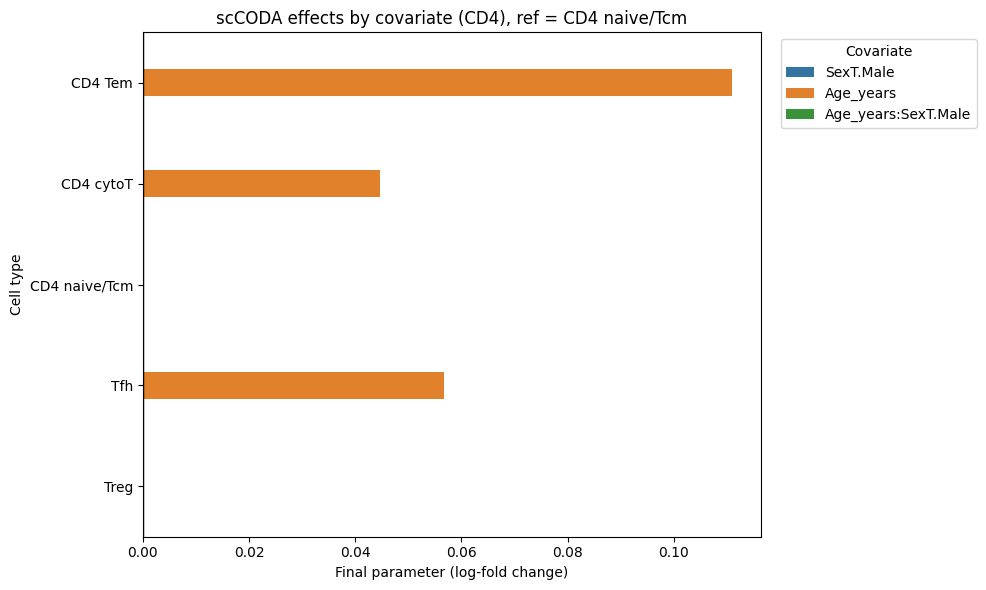

In [29]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd4_naive_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD4), ref = CD4 naive/Tcm")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

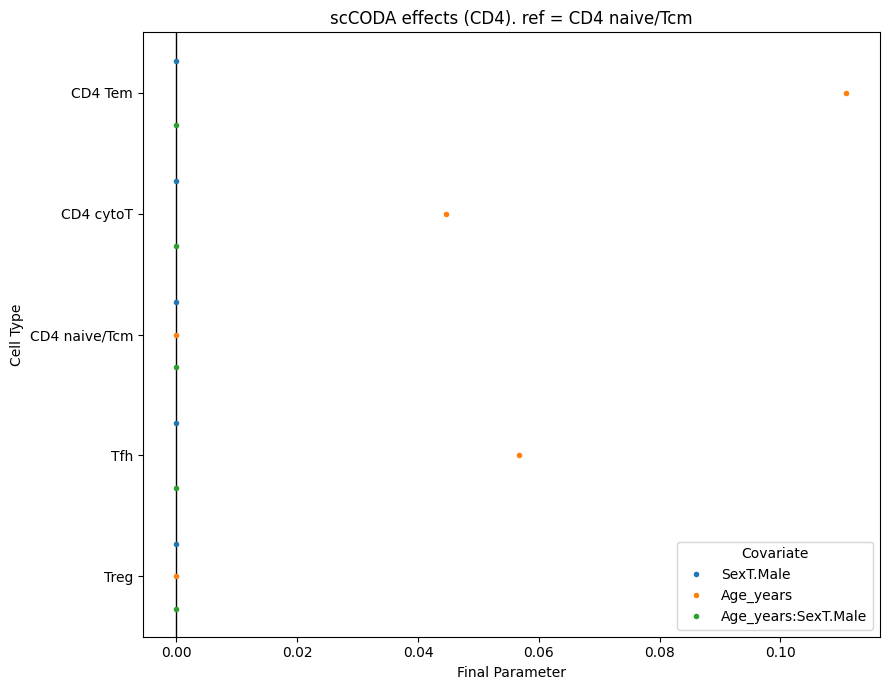

In [30]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd4_naive_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD4). ref = CD4 naive/Tcm")
plt.tight_layout()
plt.show()

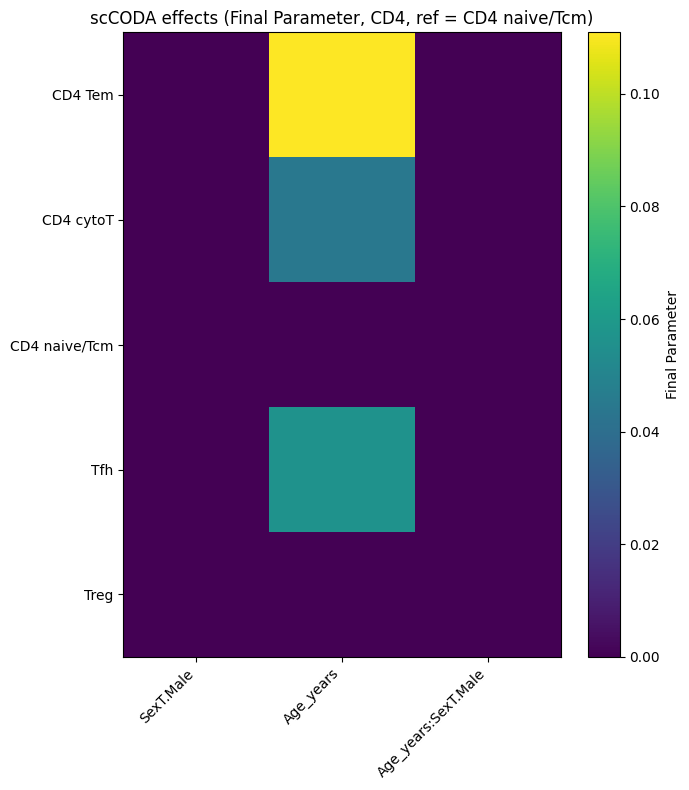

In [31]:
# inclusion pronbability heatmap
tmp_naive = effects_cd4_naive_plot.reset_index()
ip_naive = tmp_naive.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_naive = effects_cd4_naive_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_naive.values, aspect="auto")
plt.yticks(range(beta_naive.shape[0]), beta_naive.index)
plt.xticks(range(beta_naive.shape[1]), beta_naive.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD4, ref = CD4 naive/Tcm)")
plt.tight_layout()
plt.show()

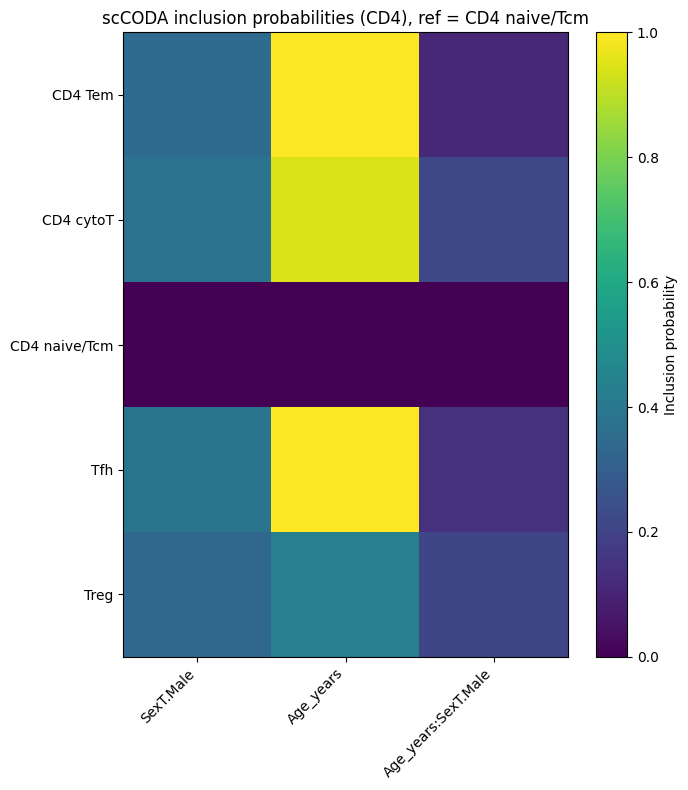

In [32]:
ip_naive = effects_cd4_naive_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_naive.values, aspect="auto")
plt.yticks(range(ip_naive.shape[0]), ip_naive.index)
plt.xticks(range(ip_naive.shape[1]), ip_naive.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD4), ref = CD4 naive/Tcm")
plt.tight_layout()
plt.show()


#### automatic ref cell type model (CD4 Tem)

In [21]:
cd4_tem = prepare_sccoda_age(sccoda_cd4.copy(), ref="CD4 Tem")

• Zero counts encountered in data! Added a pseudocount of 0.5.


In [22]:
cd4_tem  = run_sccoda(cd4_tem , rng_key=1)

sample: 100%|██████████| 7000/7000 [07:06<00:00, 16.40it/s, 511 steps of size 6.68e-03. acc. prob=0.86] 


In [23]:
sccoda_model.summary(cd4_tem , modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 5 cell types                                         │
│ Reference cell type                   │ CD4 Tem                                                                 │
│ Formula                               │ ~ Age_years * Sex + Batch                                               │
│ Reference index                       │ 0                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 86.2%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                           Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample               │
│ pica_cell_type_complete_01_gdT_corrected                                                                        │
│ CD4 Tem                                        1.810        1.665   1.952  0.077      324.544                   │
│ CD4 cytoT                                     -0.388       -0.589  -0.173  0.108       36.032                   │
│ CD4 naive/Tcm                                  4.281        3.962   4.887  0.239     3840.740                   │
│ Tfh                                            1.289        1.048   1.553  0.137      192.755                   │
│ Treg                                           1.611        1.346   1.865  0.137      265.980                   │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    Final Parameter  Expected Sample  log2-fold change                           │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem             0.000           324.544            0.000                                │
│                     CD4 cytoT           0.000            36.032            0.000                                │
│                     CD4 naive/Tcm       0.000          3840.740            0.000                                │
│                     Tfh                 0.000           192.755            0.000                                │
│                     Treg                0.000           265.980            0.000                                │
│ BatchT.Batch02      CD4 Tem             0.000           324.544            0.000                                │
│                     CD4 cytoT           0.000            36.032            0.000                                │
│                     CD4 naive/Tcm       0.000          3840.740            0.000                                │
│                     Tfh                 0.000           192.755            0.000                                │
│                     Treg                0.000           265.980            0.000                                │
│ BatchT.Batch03      CD4 Tem             0.000           324.544            0.000                                │
│                     CD4 cytoT           0.000            36.032            0.000                                │
│                     CD4 naive/Tcm       0.000          3840.740            0.000                                │
│                     Tfh                 0.000           192.755            0.000                                │
│                     Treg                0.000           265.980            0.000                                │
│ BatchT.Batch04      CD4 Tem             0.000           324.544            0.000                                │
│                     CD4 cytoT           0.000            36.032            0.000                                │
│                     CD4 naive/Tcm       0.000          3840.740            0.000                                │
│                     Tfh                 0.000           192.755            0.000                                │
│                     Treg                0.000           265.980            0.000                                │
│ BatchT.Batch05      CD4 Tem             0.000           324.544            0.000                                │
│                     CD4 cytoT           0.000            36.032            0.000                                │
│                     CD4 naive/Tcm       0.000          3840.740            0.000                                │
│                     Tfh                 0.000           192.755            0.000                                │
│                     Treg                0.000           265.980            0.000                                │
│ BatchT.Batch06      CD4 Tem             0.000           324.544            0.000                                │
│                     CD4 cytoT           0.000            36.032            0.000                                │
│                     CD4 naive/Tcm       0.000          3840.740            0.000                                │
│                     Tfh                 0.000           192.755            0.000                                │
│                     Treg                0.000         

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                    HDI 3%  HDI 97%   SD   Inclusion probability                                 │
│ Covariate           Cell Type                                                                                   │
│ SexT.Male           CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.200   0.187  0.062         0.381                                          │
│                     CD4 naive/Tcm  -0.063   0.151  0.039         0.324                                          │
│                     Tfh            -0.239   0.061  0.063         0.400                                          │
│                     Treg           -0.106   0.181  0.045         0.339                                          │
│ BatchT.Batch02      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.180   0.376  0.099         0.403                                          │
│                     CD4 naive/Tcm  -0.764   0.063  0.218         0.481                                          │
│                     Tfh            -0.248   0.154  0.070         0.355                                          │
│                     Treg           -0.427   0.084  0.113         0.443                                          │
│ BatchT.Batch03      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.317   0.232  0.089         0.378                                          │
│                     CD4 naive/Tcm  -0.728   0.104  0.202         0.410                                          │
│                     Tfh            -0.078   0.317  0.083         0.417                                          │
│                     Treg           -0.083   0.408  0.133         0.535                                          │
│ BatchT.Batch04      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.271   0.257  0.082         0.376                                          │
│                     CD4 naive/Tcm  -0.668   0.127  0.186         0.387                                          │
│                     Tfh            -0.143   0.201  0.055         0.340                                          │
│                     Treg           -0.122   0.327  0.080         0.385                                          │
│ BatchT.Batch05      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.169   0.513  0.144         0.453                                          │
│                     CD4 naive/Tcm  -0.836   0.015  0.246         0.822                                          │
│                     Tfh            -0.286   0.239  0.081         0.357                                          │
│                     Treg           -0.178   0.369  0.100         0.392                                          │
│ BatchT.Batch06      CD4 Tem         0.000   0.000  0.000         0.000                                          │
│                     CD4 cytoT      -0.483   0.142  0.134         0.471                                          │
│                     CD4 naive/Tcm  -0.731   0.104  0.204         0.413                                          │
│                     Tfh            -0.153   0.234  0.061         0.338                                          │
│                     Treg           -0.053   0.453  0.1

In [24]:
# set desired FDR globally
sccoda_model.set_fdr(cd4_tem , est_fdr=0.2, modality_key="coda")


In [25]:
# check threshold
cd4_tem ["coda"].uns["scCODA_params"]["threshold_prob"]

np.float64(0.613)

In [26]:
effects_cd4_tem= sccoda_model.get_effect_df(cd4_tem, modality_key="coda")

effects_cd4_tem["Inclusion probability"].max()
effects_cd4_tem["Inclusion probability"].describe()


count    45.000000
mean      0.335862
std       0.243419
min       0.000000
25%       0.144000
50%       0.378200
75%       0.433400
max       1.000000
Name: Inclusion probability, dtype: float64

In [27]:

# effects dataframe
effects_cd4_tem = sccoda_model.get_effect_df(cd4_tem, modality_key="coda")
effects_cd4_tem.head()

Final Parameter  HDI 3%  HDI 97%     SD  \
Covariate Cell Type                                                
SexT.Male CD4 Tem                    0.0   0.000    0.000  0.000   
          CD4 cytoT                  0.0  -0.200    0.187  0.062   
          CD4 naive/Tcm              0.0  -0.063    0.151  0.039   
          Tfh                        0.0  -0.239    0.061  0.063   
          Treg                       0.0  -0.106    0.181  0.045   

                         Inclusion probability  Expected Sample  \
Covariate Cell Type                                               
SexT.Male CD4 Tem                       0.0000       324.543725   
          CD4 cytoT                     0.3812        36.032463   
          CD4 naive/Tcm                 0.3238      3840.739757   
          Tfh                           0.3998       192.755062   
          Treg                          0.3392       265.979775   

                         log2-fold change  
Covariate Cell Type                        
SexT.Male CD4 Tem                     0.0  
          CD4 cytoT                   0.0  
          CD4 naive/Tcm               0.0  
          Tfh                         0.0  
          Treg                        0.0

In [28]:
# Filter out Batch before plotting
effects_cd4_tem_plot = effects_cd4_tem[
    ~effects_cd4_tem.index.get_level_values("Covariate").str.startswith("Batch")
]

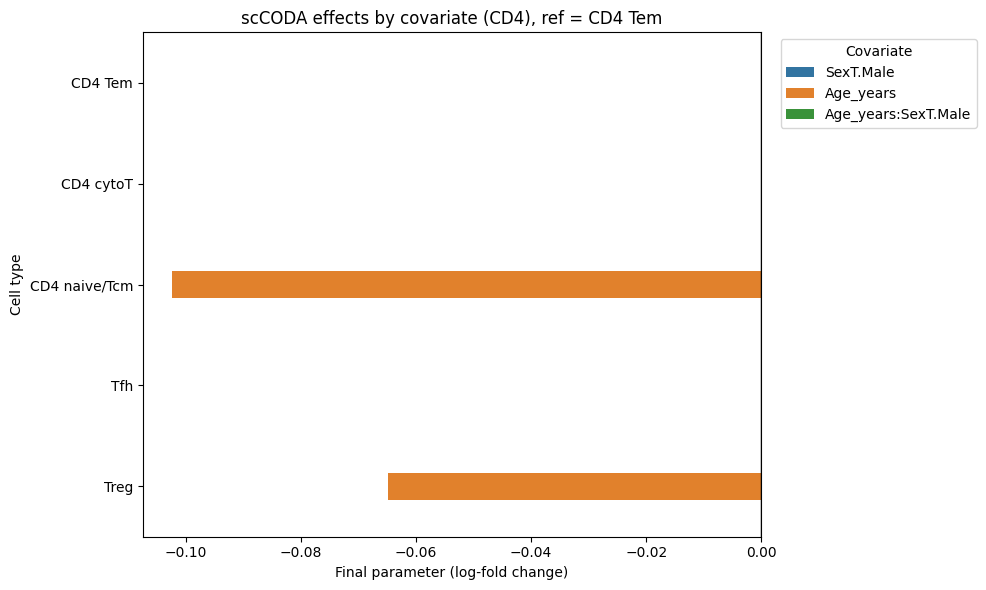

In [29]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd4_tem_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD4), ref = CD4 Tem")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

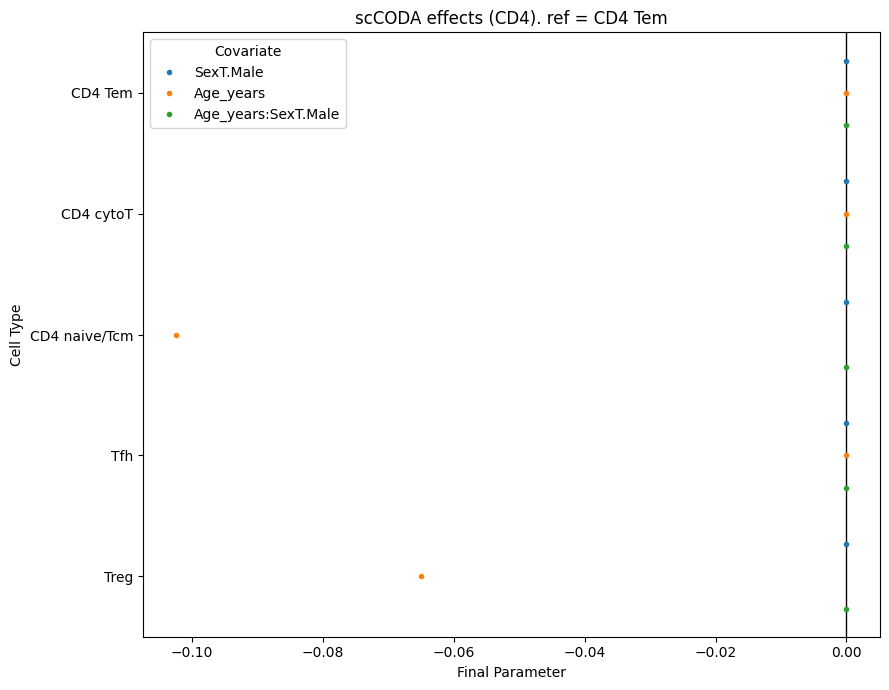

In [30]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd4_tem_plot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD4). ref = CD4 Tem")
plt.tight_layout()
plt.show()

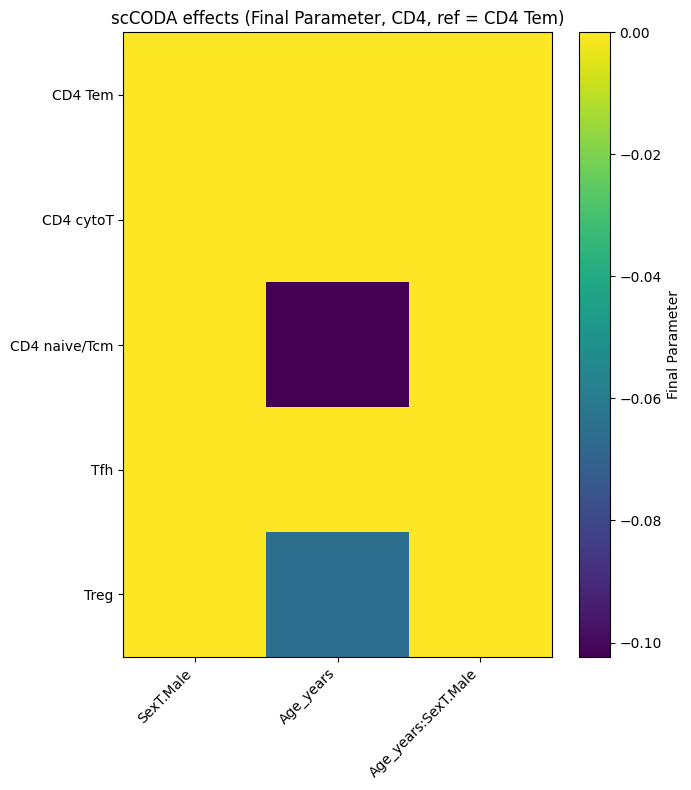

In [31]:
# inclusion pronbability heatmap
tmp_tem = effects_cd4_tem_plot.reset_index()
ip_tem = tmp_tem.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta_tem = effects_cd4_tem_plot["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta_tem.values, aspect="auto")
plt.yticks(range(beta_tem.shape[0]), beta_tem.index)
plt.xticks(range(beta_tem.shape[1]), beta_tem.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD4, ref = CD4 Tem)")
plt.tight_layout()
plt.show()

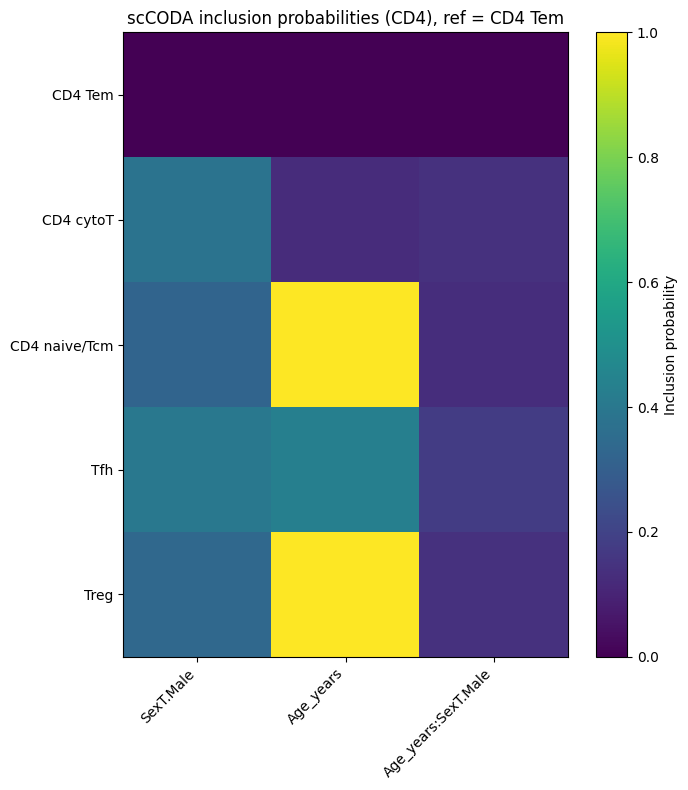

In [32]:
ip_tem = effects_cd4_tem_plot["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip_tem.values, aspect="auto")
plt.yticks(range(ip_tem.shape[0]), ip_tem.index)
plt.xticks(range(ip_tem.shape[1]), ip_tem.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD4), ref = CD4 Tem")
plt.tight_layout()
plt.show()
